In [31]:
import pandas as pd

# Create ADV graph

In [32]:
def comb_adv_results(path):
    df = pd.read_csv(path)
    new_df = pd.DataFrame()
    df = df.loc[:, df.columns.str.endswith('makespan')]
    df_dqn_no_adv = df.filter(like='TD3_no_adv_no_qrdqn')
    df_dqn_adv = df.filter(like='TD3_adv_no_qrdqn')
    df_qrdqn_no_adv = df.filter(like='TD3_no_adv_qrdqn')
    df_qrdqn_adv = df.filter(like='TD3_adv_qrdqn')
    new_df["dqn_no_adv"] = df_dqn_no_adv.mean(axis=1)
    new_df["dqn_adv"] = df_dqn_adv.mean(axis=1)
    new_df["qrdqn_no_adv"] = df_qrdqn_no_adv.mean(axis=1)
    new_df["qrdqn_adv"] = df_qrdqn_adv.mean(axis=1)
    new_df["dqn_no_adv_std"] = df_dqn_no_adv.std(axis=1)
    new_df["dqn_adv_std"] = df_dqn_adv.std(axis=1)
    new_df["qrdqn_no_adv_std"] = df_qrdqn_no_adv.std(axis=1)
    new_df["qrdqn_adv_std"] = df_qrdqn_adv.std(axis=1)
    return new_df
    # test = df_dqn_adv.mean(axis=1)
    # print(test)
    # print(df_dqn_adv.columns)
    #
    # # df_dqn_no_adv = df_dqn_no_adv.drop(columns=['TD3_no_adv_no_qrdqn_seed'])
    # print(df_dqn_no_adv.columns)
    # print(df)

df_adv_stoc = comb_adv_results("./csv_files/adv_qrdqn_exp_stochastic.csv")
df_adv_det = comb_adv_results("./csv_files/adv_qrdqn_exp_deterministic.csv")

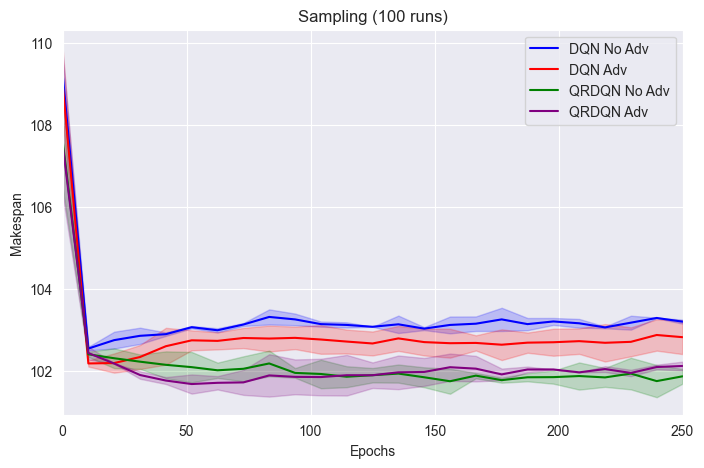

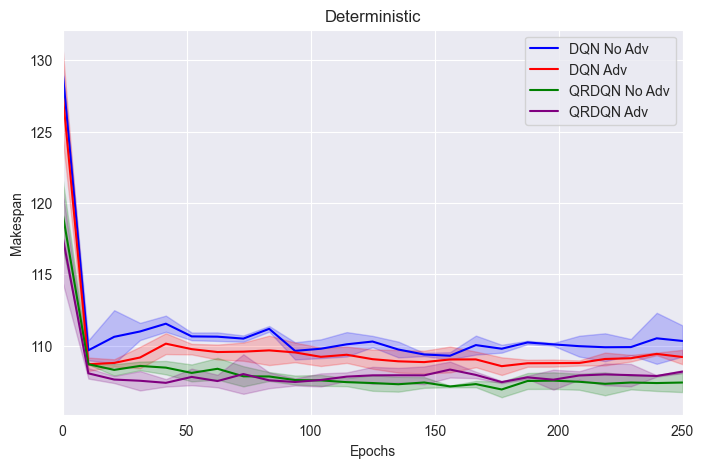

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def create_plot(df, title, save_path):
    fig, ax = plt.subplots(figsize=(8, 5))
    mean_dqn_no_adv = df["dqn_no_adv"]
    mean_dqn_adv = df["dqn_adv"]
    mean_qrdqn_no_adv = df["qrdqn_no_adv"]
    mean_qrdqn_adv = df["qrdqn_adv"]
    std_dqn_no_adv = df["dqn_no_adv_std"]
    std_dqn_adv = df["dqn_adv_std"]
    std_qrdqn_no_adv = df["qrdqn_no_adv_std"]
    std_qrdqn_adv = df["qrdqn_adv_std"]
    steps = np.linspace(0, 250, len(mean_dqn_no_adv))
    ax.plot(steps, mean_dqn_no_adv, label="DQN No Adv", color='blue')
    ax.fill_between(steps, mean_dqn_no_adv - std_dqn_no_adv, mean_dqn_no_adv + std_dqn_no_adv, alpha=0.2, color='blue')
    ax.plot(steps, mean_dqn_adv, label="DQN Adv", color='red')
    ax.fill_between(steps, mean_dqn_adv - std_dqn_adv, mean_dqn_adv + std_dqn_adv, alpha=0.2, color='red')
    ax.plot(steps, mean_qrdqn_no_adv, label="QRDQN No Adv", color='green')
    ax.fill_between(steps, mean_qrdqn_no_adv - std_qrdqn_no_adv, mean_qrdqn_no_adv + std_qrdqn_no_adv, alpha=0.2, color='green')
    ax.plot(steps, mean_qrdqn_adv, label="QRDQN Adv", color='purple')
    ax.fill_between(steps, mean_qrdqn_adv - std_qrdqn_adv, mean_qrdqn_adv + std_qrdqn_adv, alpha=0.2, color='purple')
    ax.set_title(title)
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Makespan")
    ax.legend()
    ax.set_xlim(0, 250)
    plt.savefig(save_path, dpi=600, bbox_inches='tight', transparent=True)

    # print(steps.shape)
    # print(len(mean_dqn_no_adv))


create_plot(df_adv_stoc, "Sampling (100 runs)", "./figures/adv_qrdqn_exp_stochastic.png")
create_plot(df_adv_det, "Deterministicz", "./figures/adv_qrdqn_exp_deterministic.png")

# Dataset Experiments

In [34]:
def load_dataset_exp(path):
    df = pd.read_csv(path)
    df_100 = df.filter(like="Group: 100 -").dropna()
    df_250 = df.filter(like="Group: 250 -").dropna()
    df_500 = df.filter(like="Group: 500 -").dropna()
    df_1000 = df.filter(like="Group: 1000 -").dropna()

    new_df = pd.DataFrame()
    new_df["100"] = df_100.loc[:, df_100.columns.str.endswith('makespan')].to_numpy().flatten()
    new_df["100_min"] = df_100.loc[:, df_100.columns.str.endswith('makespan__MIN')].to_numpy().flatten()
    new_df["100_max"] = df_100.loc[:, df_100.columns.str.endswith('makespan__MAX')].to_numpy().flatten()

    new_df["250"] = df_250.loc[:, df_250.columns.str.endswith('makespan')].to_numpy().flatten()
    new_df["250_min"] = df_250.loc[:, df_250.columns.str.endswith('makespan__MIN')].to_numpy().flatten()
    new_df["250_max"] = df_250.loc[:, df_250.columns.str.endswith('makespan__MAX')].to_numpy().flatten()
    new_df["500"] = df_500.loc[:, df_500.columns.str.endswith('makespan')].to_numpy().flatten()
    new_df["500_min"] = df_500.loc[:, df_500.columns.str.endswith('makespan__MIN')].to_numpy().flatten()
    new_df["500_max"] = df_500.loc[:, df_500.columns.str.endswith('makespan__MAX')].to_numpy().flatten()
    new_df["1000"] = df_1000.loc[:, df_1000.columns.str.endswith('makespan')].to_numpy().flatten()
    new_df["1000_min"] = df_1000.loc[:, df_1000.columns.str.endswith('makespan__MIN')].to_numpy().flatten()
    new_df["1000_max"] = df_1000.loc[:, df_1000.columns.str.endswith('makespan__MAX')].to_numpy().flatten()
    return new_df

df_stoc = load_dataset_exp("./csv_files/dataset_stochastic.csv")
df_det = load_dataset_exp("./csv_files/dataset_deterministic.csv")
df_det

,100,100_min,100_max,250,250_min,250_max,500,500_min,500_max,1000,1000_min,1000_max
0,145.116667,143.28,146.68,115.000000,112.82,116.50,108.806667,108.62,109.11,107.823333,107.55,108.08
1,121.573333,119.54,123.04,108.776667,108.58,109.06,108.033333,107.53,108.89,107.660000,107.37,107.90
2,111.020000,110.46,111.99,108.090000,107.93,108.33,107.446667,107.36,107.61,107.236667,106.89,107.84
3,109.416667,108.68,110.16,108.080000,107.92,108.36,107.350000,106.86,107.79,107.083333,107.00,107.15
4,109.240000,108.40,109.88,107.663333,107.30,108.35,106.980000,106.62,107.39,107.160000,106.72,107.48
5,109.053333,108.84,109.24,107.650000,107.29,108.29,106.970000,106.53,107.23,106.693333,106.58,106.91
6,108.943333,108.52,109.53,107.353333,106.69,107.86,106.910000,106.60,107.29,106.743333,106.27,107.19
7,108.730000,108.55,108.85,107.473333,106.80,108.34,106.510000,106.26,106.72,106.693333,106.22,107.02
8,108.716667,108.60,108.81,107.276667,106.74,108.03,106.990000,106.80,107.25,106.756667,106.52,107.12
9,108.823333,108.60,109.05,107.210000,106.45,107.87,106.976667,106.82,107.16,106.866667,106.39,107.64


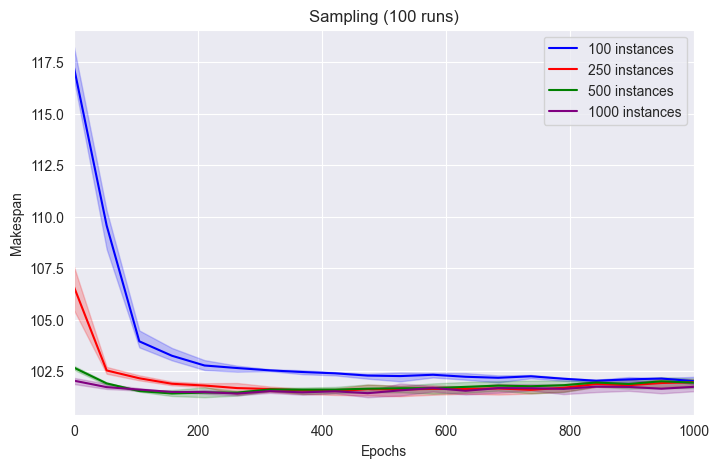

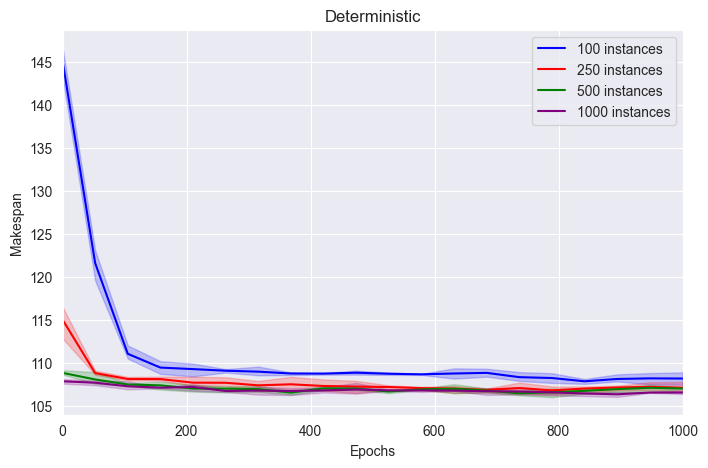

In [35]:
def create_plot_dataset(df, title, save_path):
    fig, ax = plt.subplots(figsize=(8, 5))
    mean_100 = df["100"]
    min_100 = df["100_min"]
    max_100 = df["100_max"]
    mean_250 = df["250"]
    min_250 = df["250_min"]
    max_250 = df["250_max"]
    mean_500 = df["500"]
    min_500 = df["500_min"]
    max_500 = df["500_max"]
    mean_1000 = df["1000"]
    min_1000 = df["1000_min"]
    max_1000 = df["1000_max"]

    # mean_dqn_no_adv = df["dqn_no_adv"]
    # mean_dqn_adv = df["dqn_adv"]
    # mean_qrdqn_no_adv = df["qrdqn_no_adv"]
    # mean_qrdqn_adv = df["qrdqn_adv"]
    # std_dqn_no_adv = df["dqn_no_adv_std"]
    # std_dqn_adv = df["dqn_adv_std"]
    # std_qrdqn_no_adv = df["qrdqn_no_adv_std"]
    # std_qrdqn_adv = df["qrdqn_adv_std"]
    steps = np.linspace(0, 1000, len(mean_100))
    ax.plot(steps, mean_100, label="100 instances", color='blue')
    ax.fill_between(steps, min_100, max_100, alpha=0.2, color='blue')
    ax.plot(steps, mean_250, label="250 instances", color='red')
    ax.fill_between(steps, min_250, max_250, alpha=0.2, color='red')
    ax.plot(steps, mean_500, label="500 instances", color='green')
    ax.fill_between(steps, min_500, max_500, alpha=0.2, color='green')
    ax.plot(steps, mean_1000, label="1000 instances", color='purple')
    ax.fill_between(steps, min_1000, max_1000, alpha=0.2, color='purple')
    ax.set_title(title)
    ax.set_xlabel("Epochs")
    ax.set_ylabel("Makespan")
    ax.legend()
    ax.set_xlim(0, 1000)
    plt.savefig(save_path, dpi=600, bbox_inches='tight', transparent=True)
    # plt.show()

create_plot_dataset(df_stoc, "Sampling (100 runs)", "./figures/dataset_exp_stochastic.png")
create_plot_dataset(df_det, "Deterministic", "./figures/dataset_exp_deterministic.png")
